## Importing Modules


In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

##  Loading Data

In [18]:
DATA_DIR="../dataset"
TRAIN_DIR=os.path.join(DATA_DIR, "train")
TEST_DIR=os.path.join(DATA_DIR, "test")
EMOTIONS = sorted(os.listdir(TRAIN_DIR))
print("Emotion classes found:", EMOTIONS)

Emotion classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Checking Class Distribution

In [19]:
print("Train set:")
for emotion in EMOTIONS:
    path = os.path.join(TRAIN_DIR, emotion)
    print(f"{emotion}: {len(os.listdir(path))} images")

Train set:
angry: 3995 images
disgust: 436 images
fear: 4097 images
happy: 7215 images
neutral: 4965 images
sad: 4830 images
surprise: 3171 images


In [20]:
print("Test set:")
for emotion in EMOTIONS:
    path = os.path.join(TEST_DIR, emotion)
    print(f"{emotion}: {len(os.listdir(path))} images")

Test set:
angry: 958 images
disgust: 111 images
fear: 1024 images
happy: 1774 images
neutral: 1233 images
sad: 1247 images
surprise: 831 images


## Visualizing Class Distribution

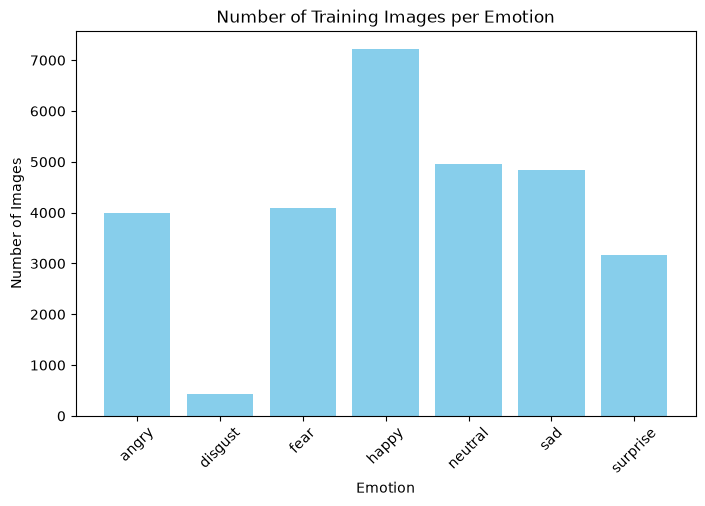

In [21]:
train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, emotion))) for emotion in EMOTIONS]
plt.figure(figsize=(8, 5))
plt.bar(EMOTIONS, train_counts, color="skyblue")
plt.title("Number of Training Images per Emotion")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

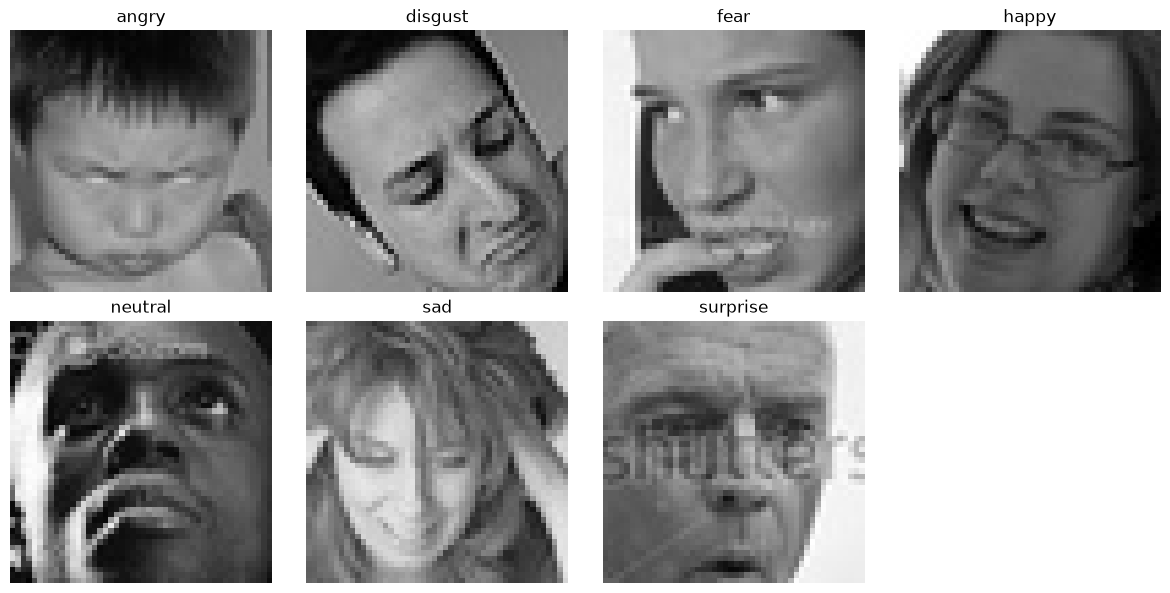

In [22]:
plt.figure(figsize=(12, 6))
for i, emotion in enumerate(EMOTIONS):
    folder = os.path.join(TRAIN_DIR, emotion)
    sample_image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, sample_image_name)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing: Data Generators

In [23]:
IMG_SIZE = 48
BATCH_SIZE = 64
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1.0/255)

In [24]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## CNN Model

In [25]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(7, activation="softmax")
])
model.summary()

c:\Users\Hp\Documents\emotion_detection (face)\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,911 (2.36 MB)

 Trainable params: 619,463 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Compiling Model & Handling Class Imbalance

In [26]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
class_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(class_labels),
    y=class_labels
)

In [28]:
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


## Training Model

In [29]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    class_weight=class_weights_dict
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 121s 252ms/step - accuracy: 0.2246 - loss: 1.9773 - val_accuracy: 0.2260 - val_loss: 1.8686
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 247ms/step - accuracy: 0.2884 - loss: 1.7933 - val_accuracy: 0.2627 - val_loss: 1.8233
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 246ms/step - accuracy: 0.3285 - loss: 1.7007 - val_accuracy: 0.3473 - val_loss: 1.6902
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 127s 282ms/step - accuracy: 0.3510 - loss: 1.6472 - val_accuracy: 0.2779 - val_loss: 1.7323
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 162s 361ms/step - accuracy: 0.3809 - loss: 1.5947 - val_accuracy: 0.4434 - val_loss: 1.4519
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 122s 272ms/step - accuracy: 0.3953 - loss: 1.5680 - val_accuracy: 0.4379 - val_loss: 1.4557
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 127s 282ms/step - accuracy: 0.4079 - loss: 1.5099 - val_accuracy: 0.4461 - val_loss: 1.4621
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 110s 244ms/step - accuracy: 0.4149 -

## Evaluating Model

In [31]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.5354 - loss: 1.2395
Test Loss: 1.2395
Test Accuracy: 0.5354


## Confusion Matrix & Classification Report

In [32]:
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step


In [33]:
cm = confusion_matrix(y_true, y_pred)

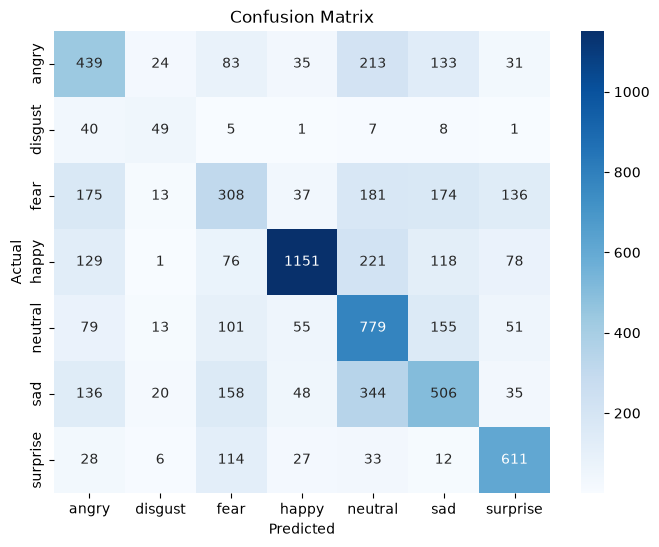

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
print(classification_report(y_true, y_pred, target_names=EMOTIONS))

              precision    recall  f1-score   support

       angry       0.43      0.46      0.44       958
     disgust       0.39      0.44      0.41       111
        fear       0.36      0.30      0.33      1024
       happy       0.85      0.65      0.74      1774
     neutral       0.44      0.63      0.52      1233
         sad       0.46      0.41      0.43      1247
    surprise       0.65      0.74      0.69       831

    accuracy                           0.54      7178
   macro avg       0.51      0.52      0.51      7178
weighted avg       0.55      0.54      0.54      7178



## Exporting Model

In [36]:
model.save("emotion_model.h5")
print("Model saved successfully!")

Model saved successfully!
